In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import warnings
warnings.filterwarnings("ignore")
import random
import math
from tqdm import tqdm
import yaml
import numpy as np
import matplotlib.pyplot as plt
from argparse import Namespace
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from momentfm import MOMENTPipeline
from momentfm.utils.anomaly_detection_metrics import adjbestf1
from data.interfaces.TelecomTS import TelecomTS

In [2]:
def control_randomness(seed: int = 77):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
with open("config.yaml", "r") as f:
        cfg = yaml.safe_load(f)

dataset_cfg = cfg.pop("dataset") 
args = Namespace(**cfg)     

In [4]:
control_randomness(args.seed)

In [5]:
DATASET_REGISTRY = {
    "TelecomTS": TelecomTS
}

In [6]:
ds_class_name = dataset_cfg["class"]

if ds_class_name not in DATASET_REGISTRY:
    raise ValueError(f"Unknown dataset class: {ds_class_name}")
    
DatasetClass = DATASET_REGISTRY[ds_class_name]

In [7]:
device = f"cuda:{args.device}" if torch.cuda.is_available() else "cpu"
device = "cpu"

In [8]:
test_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="test", conf=dataset_cfg)
test_dataloader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, drop_last=False)

[TelecomTS anomaly_detection] Selected test file: jamming_1.csv


In [9]:
sample_x, sample_mask, sample_y = test_dataset[0]

if sample_x.ndim == 1:      
    C = 1
else:                       
    C = sample_x.shape[0]

T = sample_x.shape[-1]       
H = sample_y.shape[-1]       
print(f"===== {dataset_cfg['class']} Dataset Summary =====")
print(f"=========== Task: {dataset_cfg['task']['name']} ============")
print(f"Test windows         : {len(test_dataset)}")
print(f"Channels             : {C}")
print(f"Sequence length      : {T}")
print(f"Stride               :",dataset_cfg["stride"])


===== TelecomTS Dataset Summary =====
=========== Task: anomaly_detection ============
Test windows         : 19
Channels             : 16
Sequence length      : 512
Stride               : 512


In [10]:
VARIANT_TO_MODEL = {
    "small": "AutonLab/MOMENT-1-small",
    "base":  "AutonLab/MOMENT-1-base",
    "large": "AutonLab/MOMENT-1-large",
}

VARIANT_TO_CHECKPOINT = {
    "small": "../data/checkpoints/small/TimeRAN_small.pth",
    "base": "../data/checkpoints/base/TimeRAN_base.pth",
    "large": "../data/checkpoints/large/TimeRAN_large.pth",
}

variant = args.variant.lower()
backend = args.backend

if variant not in VARIANT_TO_MODEL:
    raise ValueError(f"Unknown variant '{args.variant}'. Choose from {list(VARIANT_TO_MODEL.keys())}")

if backend not in ["TimeRAN", "MOMENT"]:
    raise ValueError("backend must be either 'TimeRAN' or 'MOMENT'")

MODEL_NAME = VARIANT_TO_MODEL[variant]

model = MOMENTPipeline.from_pretrained(
    MODEL_NAME,
    model_kwargs={"task_name": "reconstruction"}
)
model.init()

if backend == "TimeRAN":
    CHECKPOINT_PATH = VARIANT_TO_CHECKPOINT[variant]
    checkpoint_file = Path(CHECKPOINT_PATH)

    if not checkpoint_file.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_file}")

    print(f"Loading backbone: TimeRAN")
    print(f"Loading local checkpoint: {CHECKPOINT_PATH}")

    state_dict = torch.load(checkpoint_file, map_location="cpu")

    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    for k in ["head.linear.weight", "head.linear.bias"]:
        state_dict.pop(k, None)


elif backend == "MOMENT":
    print(f"Using Hugging Face pretrained MOMENT weights only: {MODEL_NAME}")

model = model.to(device)

Loading backbone: TimeRAN
Loading local checkpoint: ../data/checkpoints/base/TimeRAN_base.pth


In [11]:
trues, preds, labels = [], [], []
model.eval()
model = model.to(device).float()

with torch.no_grad():
    for batch_x, batch_masks, batch_labels in tqdm(test_dataloader, total=len(test_dataloader)):
        batch_x = batch_x.to(device).float()
        batch_masks = batch_masks.to(device)
        output = model(x_enc=batch_x, input_mask=batch_masks)
        trues.append(batch_x.detach().cpu().numpy())
        preds.append(output.reconstruction.detach().cpu().numpy())
        labels.append(batch_labels.detach().cpu().numpy())

100%|██████████| 19/19 [00:04<00:00,  4.10it/s]


In [12]:
trues  = np.concatenate(trues,  axis=0)  
preds  = np.concatenate(preds,  axis=0)  
labels = np.concatenate(labels, axis=0)  

mse_per_time = ((trues - preds) ** 2).mean(axis=1)   

anomaly_scores = mse_per_time.reshape(-1)            
y_true         = labels.reshape(-1)                  

In [13]:
print(f"Zero-shot Adjusted Best F1 Score: {adjbestf1(y_true=y_true, y_scores=anomaly_scores)}")

Zero-shot Adjusted Best F1 Score: 0.31811627310567314


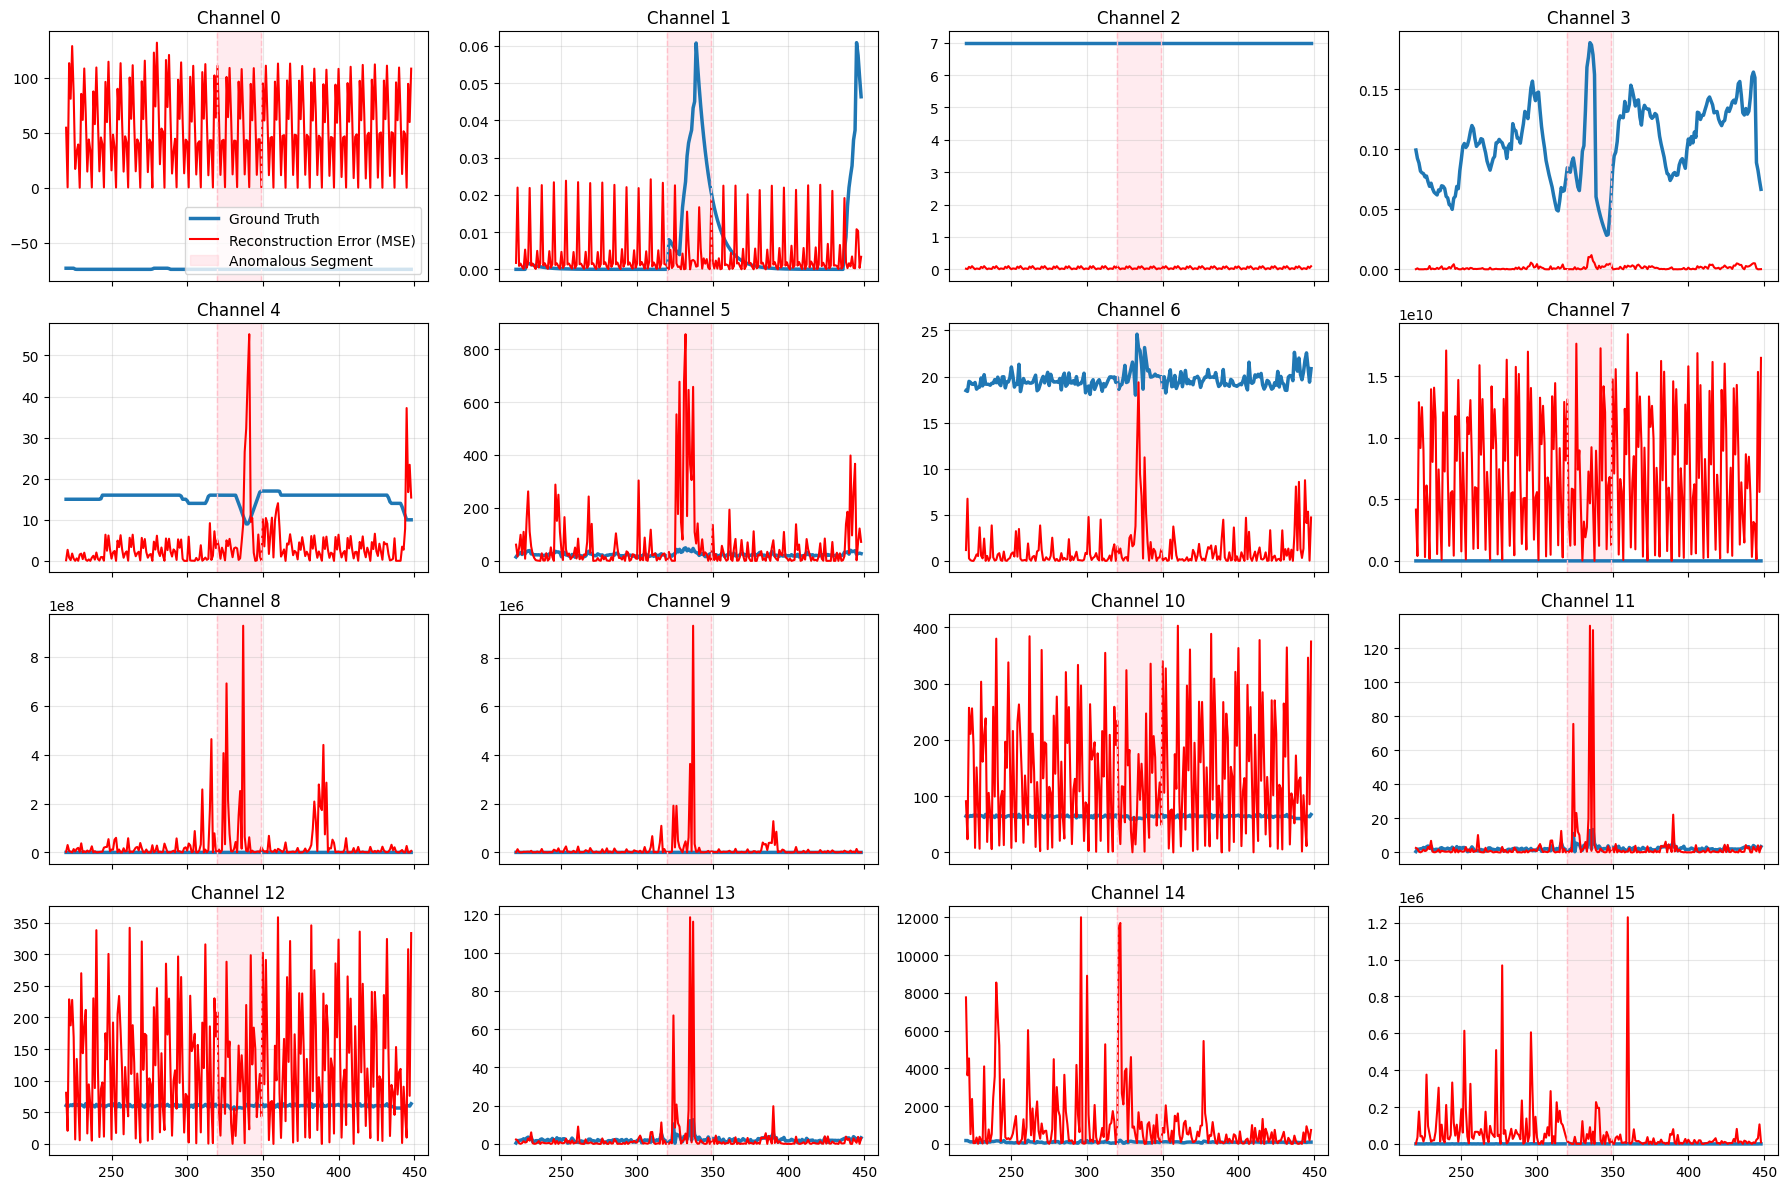

In [20]:
ch_dim = trues.shape[1]

anom_start = 320
anom_end = 349
margin = 100

total_len = trues.reshape(-1).shape[0]
start = max(0, anom_start - margin)
end   = min(total_len, anom_end + margin)

x = np.arange(start, end)
n_cols = 4
n_rows = math.ceil(ch_dim / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
axes = np.array(axes).reshape(-1)

for ch in range(ch_dim):
    ax = axes[ch]

    true_ts = trues[:, ch, :].reshape(-1)[start:end]
    mse_ts  = ((trues[:, ch, :] - preds[:, ch, :]) ** 2).reshape(-1)[start:end]

    ax.plot(x, true_ts, linewidth=2.5, label="Ground Truth" if ch == 0 else None)
    ax.plot(x, mse_ts, linewidth=1.5, color="red", label="Reconstruction Error (MSE)" if ch == 0 else None)

    ax.axvspan(anom_start, anom_end, color="pink", alpha=0.3, label="Anomalous Segment" if ch == 0 else None)
    ax.axvline(anom_start, linestyle="--", linewidth=1, color="pink")
    ax.axvline(anom_end, linestyle="--", linewidth=1, color="pink")

    ax.set_title(f"Channel {ch}")
    ax.grid(alpha=0.3)

for j in range(ch_dim, len(axes)):
    axes[j].axis("off")

if ch_dim > 0:
    axes[0].legend(loc="lower right")

plt.tight_layout()
plt.show()